# Raw Cost Estimate Panel — By Hazard Scenario

Bar panels of Script 1–4 outputs across the six hazard scenarios, from the
**updated-parameter** multihazard run (`run_multihazard_sioux_falls.py`):

- **Direct damage**, **rerouting (freight)**, **rerouting (passenger)** — in USD.
- **Isolation** — in **trips cut off** (unroutable demand), *not* a dollar cost.
  Isolation is the `Car21` demand on OD pairs left with **no path** after the
  disruption (Script 4 `isolated_od`); it is a volume of trips, so it gets its
  own axis with trip units.

Values are loaded from the run's `multihazard_summary.csv` when present, else
from embedded correct values so the notebook renders standalone.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

for _weight_file in ("verdana.ttf", "verdanab.ttf", "verdanai.ttf", "verdanaz.ttf"):
    try:
        fm.fontManager.addfont(f"C:/Windows/Fonts/{_weight_file}")
    except FileNotFoundError:
        pass

In [2]:
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "resiflow").is_dir():
            return p
    return start


REPO = _find_repo_root(Path.cwd())

HAZARDS = ["Flood surface", "Flood river", "Flood coastal", "Earthquake", "Landslide", "Winter storm"]
SCEN = [301, 302, 303, 401, 501, 601]

# Correct values from the updated-parameter six-hazard run:
#   python scripts/testbed/run_multihazard_sioux_falls.py --output-root results/multihazard_new_params
# Costs in USD; isolation in isolated trips (Car21 demand on unroutable OD pairs).
# Embedded so the notebook is standalone; auto-refreshed from the summary CSV if present.
_FALLBACK = {
    "direct_damage_usd":            [363.24, 4060.57, 0.00, 1061.49, 363.24, 363.24],
    "rerouting_cost_freight_usd":   [1296.07, 2815.15, 1296.07, 2786.50, 1296.07, 1296.07],
    "rerouting_cost_passenger_usd": [14400.75, 31279.45, 14400.75, 30961.12, 14400.75, 14400.75],
    "isolation_flow":               [0.0, 29528.1, 0.0, 29528.1, 0.0, 0.0],
}

_csv = REPO / "results" / "multihazard_new_params" / "multihazard_summary.csv"
if _csv.exists():
    _s = pd.read_csv(_csv).set_index("scenario_param")
    data = {k: [float(_s.loc[sp, k]) for sp in SCEN] for k in _FALLBACK}
    print(f"Loaded live values from {_csv}")
else:
    data = _FALLBACK
    print("Summary CSV not found - using embedded correct values.")

df = pd.DataFrame({"hazard_label": HAZARDS, "scenario_param": SCEN, **data})
# to thousands for plotting
df["direct_damage"] = df["direct_damage_usd"] / 1e3
df["rerouting_cost_freight"] = df["rerouting_cost_freight_usd"] / 1e3
df["rerouting_cost_passenger"] = df["rerouting_cost_passenger_usd"] / 1e3
df["isolation_trips"] = df["isolation_flow"] / 1e3
df

Loaded live values from C:\Users\trillion244\Documents\GitHub\ResiFlow\results\multihazard_new_params\multihazard_summary.csv


,hazard_label,scenario_param,direct_damage_usd,rerouting_cost_freight_usd,rerouting_cost_passenger_usd,isolation_flow,direct_damage,rerouting_cost_freight,rerouting_cost_passenger,isolation_trips
0,Flood surface,301,363.242870,1296.067454,14400.749492,0.0,0.363243,1.296067,14.400749,0.0000
1,Flood river,302,4060.566951,2815.150667,31279.451857,29528.1,4.060567,2.815151,31.279452,29.5281
2,Flood coastal,303,0.000000,1296.067454,14400.749492,0.0,0.000000,1.296067,14.400749,0.0000
3,Earthquake,401,1061.494478,2786.500398,30961.115532,29528.1,1.061494,2.786500,30.961116,29.5281
4,Landslide,501,363.242870,1296.067454,14400.749492,0.0,0.363243,1.296067,14.400749,0.0000
5,Winter storm,601,363.242870,1296.067454,14400.749492,0.0,0.363243,1.296067,14.400749,0.0000


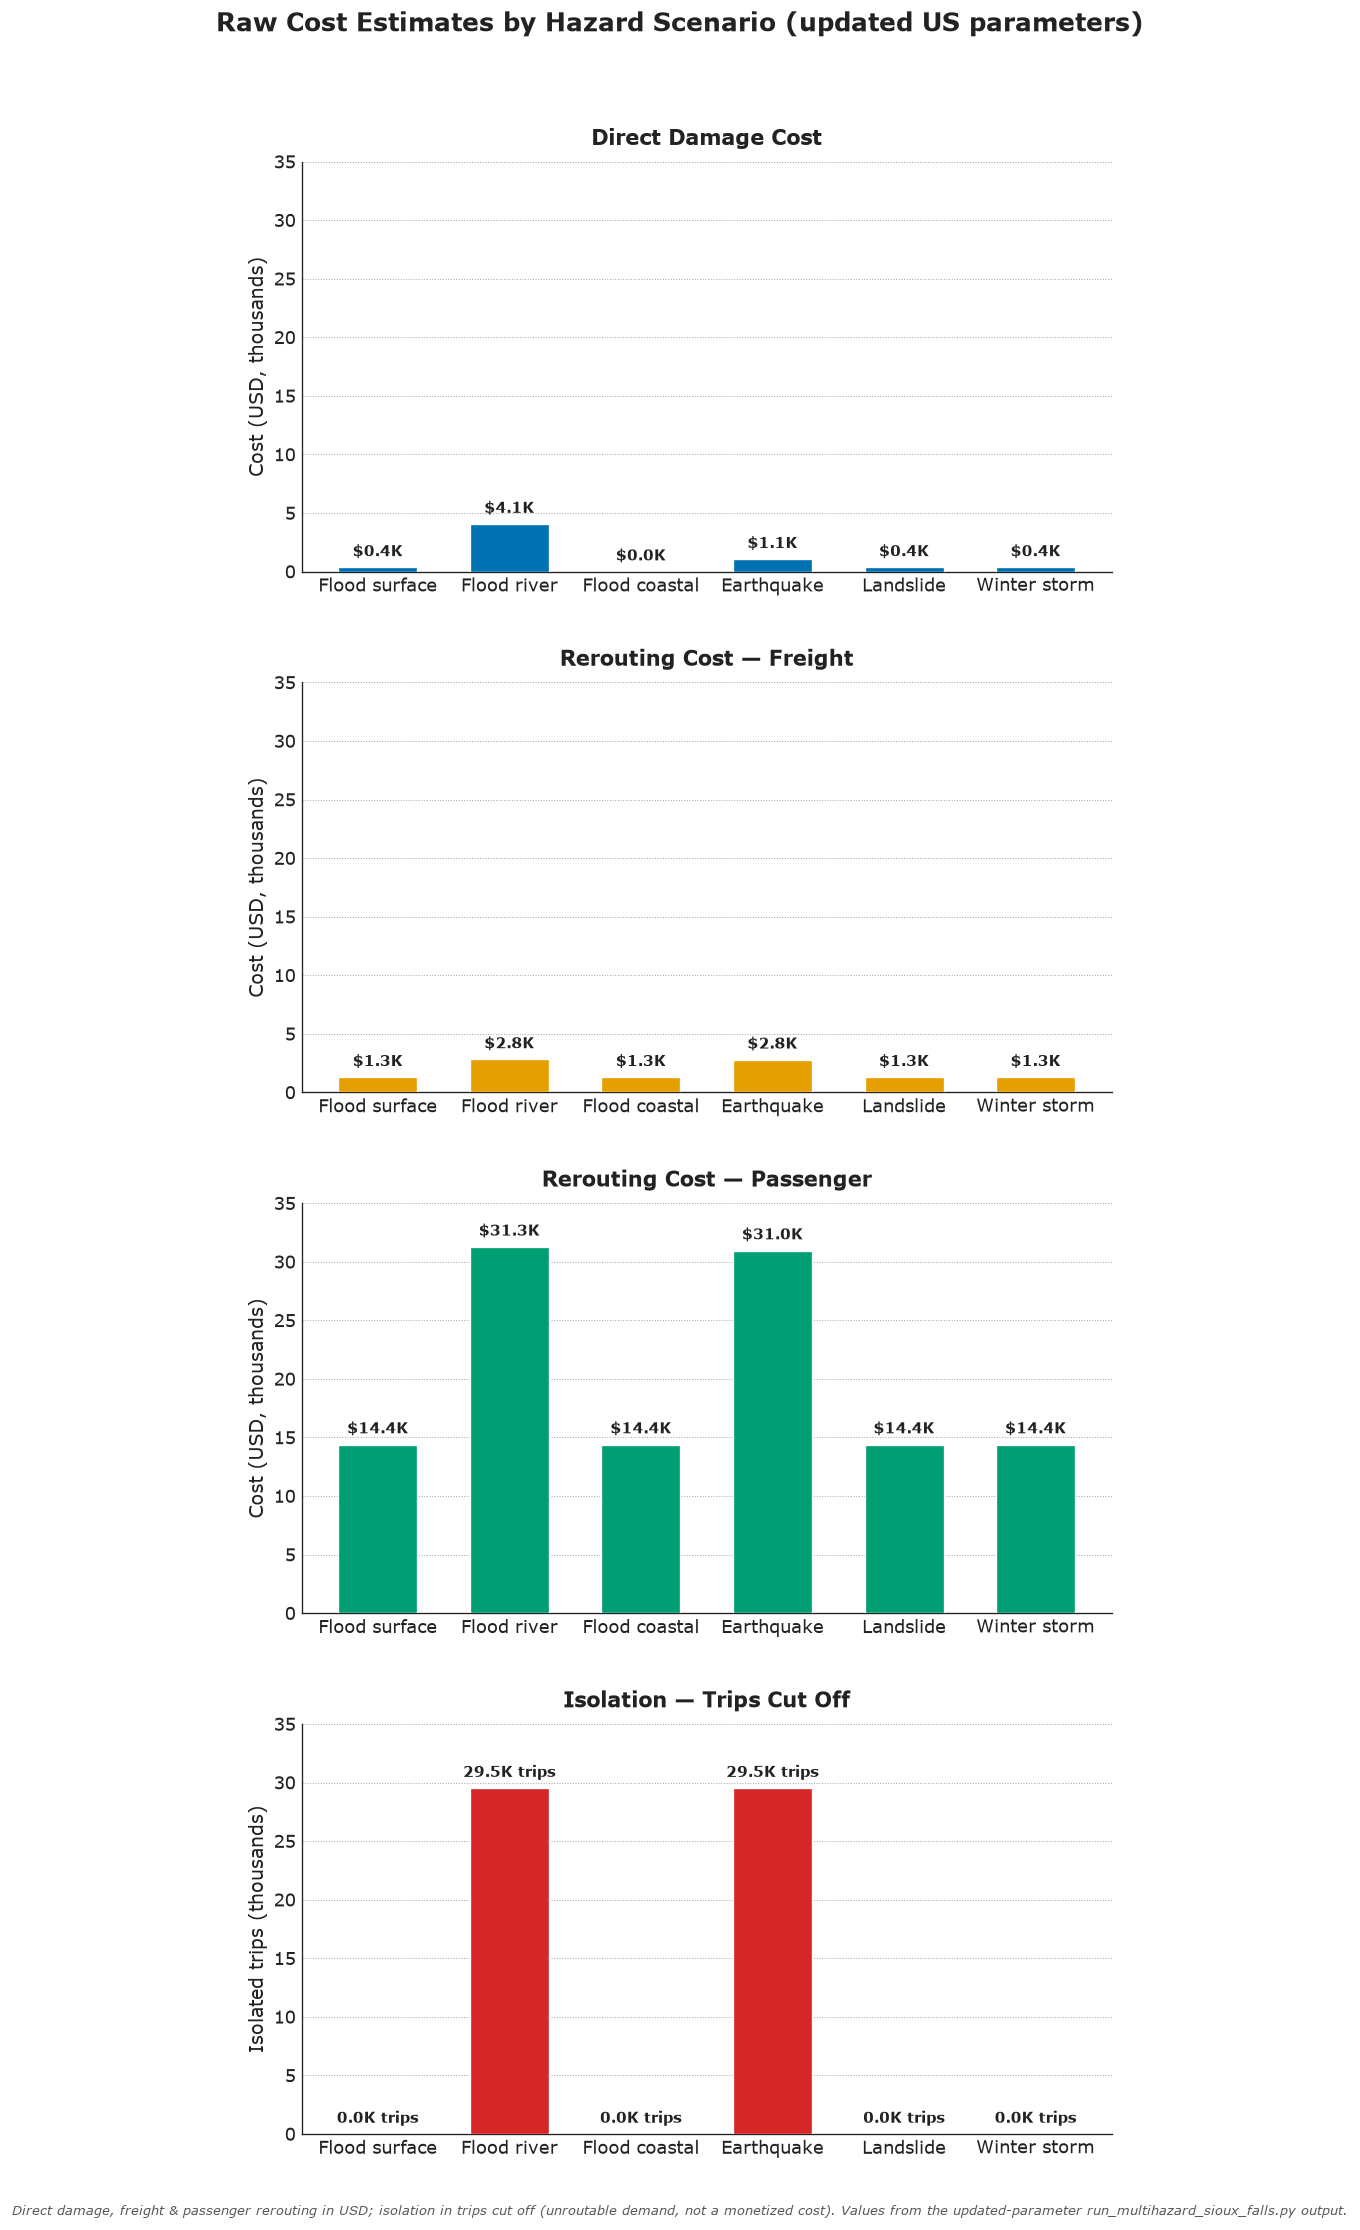

In [3]:
FONT = "Verdana"
BG = "white"
FG = "#222222"

# (column, title, color, unit) -- unit drives the axis label and value formatting
PANELS = [
    ("direct_damage", "Direct Damage Cost", "#0072B2", "usd"),
    ("rerouting_cost_freight", "Rerouting Cost \u2014 Freight", "#E69F00", "usd"),
    ("rerouting_cost_passenger", "Rerouting Cost \u2014 Passenger", "#009E73", "usd"),
    ("isolation_trips", "Isolation \u2014 Trips Cut Off", "#D62728", "trips"),
]


def fmt(v, unit):
    return f"${v:.1f}K" if unit == "usd" else f"{v:.1f}K trips"


fig, axes = plt.subplots(4, 1, figsize=(7.5, 18.5), dpi=120)
fig.patch.set_facecolor(BG)
x = np.arange(len(df))
xticklabels = list(df["hazard_label"])

# Common numeric scale so bar heights are comparable; note the isolation panel's
# axis is in trips (thousands), the three cost panels are in USD (thousands).
Y_TOP = 35.0
Y_TICKS = np.arange(0, Y_TOP + 1, 5)
headroom = Y_TOP * 0.02

for ax, (col, title, color, unit) in zip(axes, PANELS):
    ax.set_facecolor(BG)
    vals = df[col].values
    bars = ax.bar(x, vals, color=color, width=0.6, edgecolor="white", linewidth=0.8, zorder=3)
    for rect, v in zip(bars, vals):
        ax.text(
            rect.get_x() + rect.get_width() / 2, rect.get_height() + headroom, fmt(v, unit),
            ha="center", va="bottom", fontsize=8.8, fontweight="bold", fontfamily=FONT, color=FG,
        )
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels, fontfamily=FONT, fontsize=10.5, color=FG)
    ax.set_title(title, fontsize=12.5, fontweight="bold", fontfamily=FONT, color=FG, pad=10)
    ax.set_ylabel(
        "Cost (USD, thousands)" if unit == "usd" else "Isolated trips (thousands)",
        fontsize=11.5, fontfamily=FONT, color=FG,
    )
    ax.set_yticks(Y_TICKS)
    ax.set_ylim(0, Y_TOP)
    for lbl in ax.get_yticklabels():
        lbl.set_fontfamily(FONT)
        lbl.set_color(FG)
        lbl.set_fontsize(10.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(FG)
    ax.spines["bottom"].set_color(FG)
    ax.tick_params(colors=FG, length=0)
    ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.4, color=FG, zorder=0)

fig.suptitle(
    "Raw Cost Estimates by Hazard Scenario (updated US parameters)",
    fontsize=15, fontweight="bold", fontfamily=FONT, color=FG, y=0.995,
)
fig.text(
    0.5, 0.001,
    "Direct damage, freight & passenger rerouting in USD; isolation in trips cut off "
    "(unroutable demand, not a monetized cost). Values from the updated-parameter "
    "run_multihazard_sioux_falls.py output.",
    fontsize=8, fontfamily=FONT, color=FG, alpha=0.75, ha="center", va="bottom", style="italic",
)
fig.tight_layout(rect=(0, 0.02, 1, 0.97), h_pad=3.2)
plt.show()

In [4]:
fig.savefig("raw_cost_estimate_panel.png", dpi=300, bbox_inches="tight")
print("saved raw_cost_estimate_panel.png")

saved raw_cost_estimate_panel.png
